<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/PracticaBookCrossing_AlvaroHernandez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploración y recomendación no personalizada de libros**

* Asignatura: Sistemas de recomendación
* Profesor: Dra. Karla Olmos Sánchez
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* Fecha de entrega: 2 de septiembre de 2026




## 1. Propósito
Construir e interpretar el perfil de un usuario a partir de sus valoraciones de libros. La práctica busca que el estudiante transfiera la lógica trabajada con MovieLens a un dominio diferente, identificando qué datos representan las interacciones del usuario, cómo deben integrarse con la información de los ítems y cómo pueden transformarse en una representación útil de sus preferencias.


**Importante**: en esta tarea no se proporciona código. El estudiante deberá decidir qué operaciones necesita realizar y traducir el proceso conceptual a Python.


## 2. Datos a utilizar
Utiliza el dataset Book Recommendation Dataset basado en Book-Crossing. Trabajarás principalmente con los archivos de valoraciones y libros.

Archivo | Información relevante
--- | ---
Ratings.csv | Identificador de usuario, ISBN y valoración del libro.
Books.csv | ISBN, título, autor, año de publicación y editorial.
Users.csv | Información adicional del usuario. Su análisis es opcional.


**Criterio para esta práctica**: trabaja inicialmente con valoraciones explícitas mayores que cero. Al final deberás explicar qué significa excluir las interacciones registradas con valoración igual a cero y qué información podría perderse.


## 3. Preparación del entorno

### 3.1 Importar bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### 3.2 Cargar los archivos

In [2]:
books = pd.read_csv(
    "/content/drive/MyDrive/MIAAD_05_SistemasDeRecomendacion/Books.csv",
    sep=",",
    encoding="latin-1",
    on_bad_lines="skip",
    low_memory=False
)

ratings = pd.read_csv(
    "/content/drive/MyDrive/MIAAD_05_SistemasDeRecomendacion/Ratings.csv",
    sep=",",
    encoding="latin-1",
    on_bad_lines="skip"
)

users = pd.read_csv(
    "/content/drive/MyDrive/MIAAD_05_SistemasDeRecomendacion/Users.csv",
    sep=",",
    encoding="latin-1",
    on_bad_lines="skip"
)

## 4. Proceso de la práctica

### 4.1 Explorar el conjunto de datos
* Revisa la estructura de los archivos, nombres de atributos, cantidad de registros, valores faltantes y tipos de información disponibles.
* Identifica qué archivo representa usuarios, qué archivo representa ítems y cuál representa la interacción usuario–ítem.

In [3]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [4]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [5]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [6]:
print(f"Books.csv. Filas: {books.shape[0]:,} y columnas: {books.shape[1]}")
print(f"Ratings.csv. Filas: {ratings.shape[0]:,} y columnas: {ratings.shape[1]}")
print(f"Users.csv. Filas: {users.shape[0]:,} y columnas: {users.shape[1]}")

Books.csv. Filas: 271,360 y columnas: 8
Ratings.csv. Filas: 1,149,780 y columnas: 3
Users.csv. Filas: 278,858 y columnas: 3


In [7]:
print("============Tipos de datos de Books.csv============")
print(books.info())
print()
print("============Tipos de datos de Ratings.csv============")
print(ratings.info())
print()
print("============Tipos de datos de Users.csv============")
print(users.info())


============Tipos de datos de Books.csv============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB
None

============Tipos de datos de Ratings.csv============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int

`Year-Of-Publication` está cargado como `object`, no es un dato numérico.

In [8]:
print("== Valores faltantes en Books.csv ==")
print(books.isna().sum())
print()
print("== Valores faltantes en Ratings.csv ==")
print(ratings.isna().sum())
print()
print("== Valores faltantes en Users.csv ==")
print(users.isna().sum())

== Valores faltantes en Books.csv ==
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

== Valores faltantes en Ratings.csv ==
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

== Valores faltantes en Users.csv ==
User-ID          0
Location         0
Age         110762
dtype: int64


In [9]:
print(f"Registros duplicados en Books.csv: {books.duplicated().sum()}")
print(f"Registros duplicados en Ratings.csv: {ratings.duplicated().sum()}")
print(f"Registros duplicados en Users.csv: {users.duplicated().sum()}")

Registros duplicados en Books.csv: 0
Registros duplicados en Ratings.csv: 0
Registros duplicados en Users.csv: 0


In [10]:
duplicadas = ratings.duplicated(subset=["User-ID", "ISBN"], keep=False)
print(f"Filas duplicadas: {duplicadas.sum()}")

Filas duplicadas: 0


Debido a que no hay filas duplicadas en la combinación `User-ID` con `ISBN`, `Ratings.csv` significa el número de interacciones de un usuario con un libro.

### 4.2. Identificar usuarios con suficiente información.
* Determina cuántas valoraciones explícitas tiene cada usuario.
* Selecciona un usuario con suficientes interacciones para construir un perfil razonablemente informativo.
* Justifica por qué elegiste ese usuario.

In [11]:
print(ratings["Book-Rating"].value_counts().sort_index())

explicit_ratings = ratings[
    ratings["Book-Rating"].between(1, 10)
].copy()

implicit_ratings = ratings[
    ratings["Book-Rating"] == 0
].copy()

print(f"\nValoraciones explícitas: {len(explicit_ratings):,}")
print(f"Interacciones implícitas: {len(implicit_ratings):,}")

Book-Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64

Valoraciones explícitas: 433,671
Interacciones implícitas: 716,109


In [12]:
interactions_user = explicit_ratings.groupby("User-ID", observed=False).size().sort_values(ascending=False)
print(f"Interaccions por usuario: {interactions_user.head(50)}")

Interaccions por usuario: User-ID
11676     8524
98391     5802
153662    1969
189835    1906
23902     1395
76499     1036
171118    1035
235105    1023
16795      968
248718     948
56399      911
35859      829
63714      811
197659     806
185233     723
95359      619
114368     614
101851     591
177458     584
158295     569
76626      564
78973      558
3757       523
69078      522
93047      516
182085     512
204864     510
23872      508
49144      501
189334     498
100906     494
135149     493
107784     489
60244      481
257204     476
123883     454
129074     453
88733      442
234828     430
87141      425
249894     424
193560     411
31826      405
56959      395
262998     387
216012     385
104636     378
56271      364
51883      363
55490      362
dtype: int64


In [13]:
print(interactions_user.describe())

count    77805.000000
mean         5.573819
std         44.001879
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       8524.000000
dtype: float64


Elegí al **usuario 55490** por tener **362** valoraciones explícitas. Este número de interacciones nos ayudará a construir un perfil con buena información. Evito usuarios con muchas valoraciones, por ejemplo, aquellos que están por encima de 1,000, que son solo 8.

### 4.3. Extraer el historial del usuario.
* Obtén únicamente las valoraciones realizadas por el usuario seleccionado.
* Analiza cuántos libros ha valorado y la distribución de sus calificaciones.

In [14]:
user_id = 55490

user_profile = explicit_ratings[explicit_ratings["User-ID"] == user_id].copy()

print(user_profile.head())
print("Número de valoraciones:" , len(user_profile))

        User-ID        ISBN  Book-Rating
237910    55490  0020518501            8
237911    55490  0028618874           10
237912    55490  0028621573            7
237913    55490  0028621697           10
237914    55490  0029356504            8
Número de valoraciones: 362


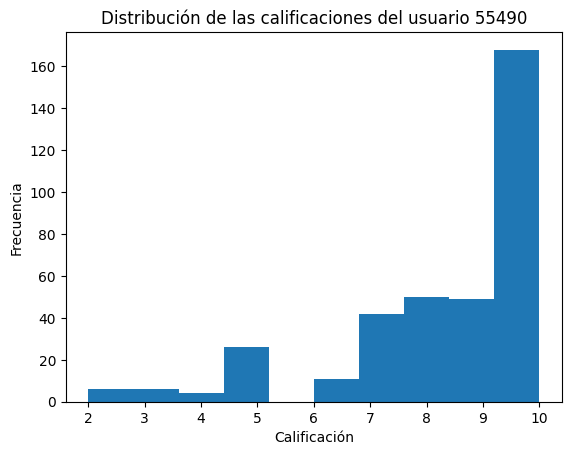

In [15]:
plt.hist(user_profile["Book-Rating"], bins=10)
plt.xlabel("Calificación")
plt.ylabel("Frecuencia")
plt.title("Distribución de las calificaciones del usuario 55490")
plt.show()

### 4.4. Relacionar las valoraciones con los libros.
* Integra el historial del usuario con la información descriptiva de los libros utilizando el ISBN como identificador común.
* Comprueba si todas las valoraciones pueden asociarse con un registro de libro.

In [16]:
user_profile = user_profile.merge(
    books[["ISBN", "Book-Title", "Book-Author", "Publisher", "Year-Of-Publication"]],
    on="ISBN",
    how="left"
)

print(user_profile[["ISBN", "Book-Title", "Book-Author", "Publisher", "Year-Of-Publication", "Book-Rating"]].head())
print("Número de valoraciones:", len(user_profile))

         ISBN                                         Book-Title  \
0  0020518501  For Whome the Bell Tolls  (REISSUE) (A Scribne...   
1  0028618874              Webster's New World Pocket Dictionary   
2  0028621573             Webster's New World Pocket Style Guide   
3  0028621697         The New York Public Library Desk Reference   
4  0029356504  Medieval Philosophy : From St. Augustine To Ni...   

            Book-Author               Publisher Year-Of-Publication  \
0      Ernest Hemingway  Scribner Paper Fiction                1987   
1               Webster   John Wiley &amp; Sons                1997   
2       John A.  Haslem     Webster's New World                1998   
3  Macmillan Publishing           MacMillan USA                1998   
4        John F. Wippel              Free Press                1969   

   Book-Rating  
0            8  
1           10  
2            7  
3           10  
4            8  
Número de valoraciones: 362


In [17]:
missing_title = user_profile["Book-Title"].isna().sum()
missing_author = user_profile["Book-Author"].isna().sum()
missing_publisher = user_profile["Publisher"].isna().sum()

print(f"Valoraciones sin título: {missing_title}")
print(f"Valoraciones sin autor: {missing_author}")
print(f"Valoraciones sin editorial: {missing_publisher}")

Valoraciones sin título: 37
Valoraciones sin autor: 37
Valoraciones sin editorial: 37


37 de 362 valoraciones no tienen registro en `Books.csv`, un poco más del 10%.

In [18]:
missing_books = user_profile[
    user_profile["Book-Title"].isna()
].copy()

print(f"Total de valoraciones sin información del libro: {len(missing_books)}")

display(
    missing_books[
        ["User-ID", "ISBN", "Book-Rating",
         "Book-Title", "Book-Author", "Publisher", "Year-Of-Publication"]
    ].sort_values("ISBN")
)

Total de valoraciones sin información del libro: 37


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Publisher,Year-Of-Publication
23,55490,00898910382,6,NaN,NaN,NaN,NaN
24,55490,0099637812,8,NaN,NaN,NaN,NaN
40,55490,0312487975,9,NaN,NaN,NaN,NaN
101,55490,0399135863,9,NaN,NaN,NaN,NaN
141,55490,0451078810,7,NaN,NaN,NaN,NaN
217,55490,0676396860,8,NaN,NaN,NaN,NaN
232,55490,070049300,7,NaN,NaN,NaN,NaN
236,55490,0747257906,8,NaN,NaN,NaN,NaN
301,55490,0943365023,2,NaN,NaN,NaN,NaN
302,55490,0943365120,2,NaN,NaN,NaN,NaN


Esos 37 registros no cuentan con datos en `Books.csv`, por lo que no tenemos datos de ellos.

### 4.5. Construir un perfil por autor.
* Agrupa los libros valorados por autor.
* Para cada autor, determina al menos cuántos libros ha valorado el usuario y cuál es su valoración promedio.
* Analiza por qué frecuencia y valoración aportan información diferente.

In [19]:
user_profile_clean = user_profile.dropna(subset=["Book-Author"])

author_profile = (
    user_profile_clean.groupby("Book-Author")
    .agg(
        libros=("ISBN", "count"),
        rating_promedio=("Book-Rating", "mean")
    )
    .reset_index()
)


print(author_profile)

             Book-Author  libros  rating_promedio
0        A. A. Attanasio       1        10.000000
1             ALEX HALEY       1         8.000000
2              ANNE RICE       3         9.666667
3               Ada Muir       1         6.000000
4       Alan Dean Foster       1         5.000000
..                   ...     ...              ...
230       Visible Ink Pr       1        10.000000
231              Webster       2        10.000000
232    William A. Barton       1        10.000000
233       William Gibson       1        10.000000
234  William Shakespeare       3         9.666667

[235 rows x 3 columns]


In [20]:
frecuencia = author_profile.sort_values(
    "libros",
    ascending=False
).head(20)

print("=== Libros valorados por el usuario por autor ===")
print(frecuencia[["Book-Author", "libros", "rating_promedio"]].to_string(index=False))

=== Libros valorados por el usuario por autor ===
        Book-Author  libros  rating_promedio
     Dean R. Koontz      14         8.785714
       Stephen King      14         8.928571
    James Patterson       7         8.142857
      Frank Herbert       6        10.000000
      Margaret Weis       6         9.000000
   Michael Moorcock       6        10.000000
          Anne Rice       6         8.333333
    Katherine Kurtz       3         5.666667
     Bill Watterson       3        10.000000
          ANNE RICE       3         9.666667
    Mercedes Lackey       3        10.000000
      Kurt Vonnegut       3         9.333333
   Orson Scott Card       3         8.333333
        Neil Gaiman       3        10.000000
   Raymond E. Feist       3        10.000000
       Tad Williams       3        10.000000
William Shakespeare       3         9.666667
         Robin Cook       3         5.000000
    Kevin Siembieda       2         7.500000
   John C. Traupman       2         9.500000


In [21]:
rating = author_profile[
    author_profile["libros"] >= 2
].sort_values(
    "rating_promedio",
    ascending=False
).head(20)

print("\n=== Valoración promedio por autor ===")
print(rating[["Book-Author", "libros", "rating_promedio"]].to_string(index=False))


=== Valoración promedio por autor ===
        Book-Author  libros  rating_promedio
      Brian Herbert       2        10.000000
     Bill Watterson       3        10.000000
       Tad Williams       3        10.000000
      Thomas Harris       2        10.000000
    CHUCK PALAHNIUK       2        10.000000
      George Orwell       2        10.000000
      Frank Herbert       6        10.000000
   Michael Moorcock       6        10.000000
    Mercedes Lackey       3        10.000000
            Webster       2        10.000000
        Neil Gaiman       3        10.000000
  Madeleine L'Engle       2        10.000000
     Poppy Z. Brite       2        10.000000
   Raymond E. Feist       3        10.000000
William Shakespeare       3         9.666667
          ANNE RICE       3         9.666667
          Ira Levin       2         9.500000
    Chuck Palahniuk       2         9.500000
   John C. Traupman       2         9.500000
      Kurt Vonnegut       3         9.333333


El número de libros que lee el usuario por autor nos muestra lo que lee el usuario. Cuando tenemos muchos libros leídos de un autor nos indica que el usuario lee mucho su obra. Pero aunque sean muchos, no significa que estén valorados altos.
La valoración promedio nos muestra más claramente la valoración del usuario de la obra de un autor. Solo que si tiene uno o dos libros, puede ser engañoso, por eso filtré a los que tienen minimo dos valoraciones. En conclusión, las dos medidas nos brindan información importante y complementaria sobre las preferencias del usuario.

### 4.6. Construir un perfil por editorial.
* Realiza un análisis equivalente por editorial.
* Identifica qué editoriales aparecen con mayor frecuencia y cuáles reciben mejores valoraciones.

In [22]:
user_profile_pub = user_profile.dropna(subset=["Publisher"]).copy()

publisher_profile = (
    user_profile_pub.groupby("Publisher")
    .agg(
        libros=("ISBN", "count"),
        rating_promedio=("Book-Rating", "mean")
    )
    .reset_index()
)


print(publisher_profile)

                        Publisher  libros  rating_promedio
0                     ACE Charter       1        10.000000
1                          AMACOM       1         3.000000
2                  Academic Press       1        10.000000
3                  Addison-Wesley       1         8.000000
4                 Alfred A. Knopf       4         8.500000
..                            ...     ...              ...
169                William Morrow       1        10.000000
170  William Morrow &amp; Company       3         8.333333
171          Wizards of the Coast       3        10.000000
172               Word Publishing       1         7.000000
173         Writer's Digest Books       1         8.000000

[174 rows x 3 columns]


In [23]:
frecuencia_p = publisher_profile.sort_values(
    "libros",
    ascending=False
).head(20)

print("=== Libros valorados por el usuario por editorial ===")
print(frecuencia_p[["Publisher", "libros", "rating_promedio"]].to_string(index=False))

=== Libros valorados por el usuario por editorial ===
                   Publisher  libros  rating_promedio
            Ballantine Books      15         7.666667
    Berkley Publishing Group      13         8.000000
                 Signet Book      12         8.500000
                      Bantam      10         8.800000
               Harpercollins       7        10.000000
                Bantam Books       7         9.428571
                Warner Books       6         8.166667
          Dover Publications       5         8.200000
              Chaosium, Inc.       5         9.200000
               Del Rey Books       5         7.200000
       Bantam Dell Pub Group       4         9.250000
             Alfred A. Knopf       4         8.500000
                   Daw Books       4        10.000000
                   DC Comics       4         9.750000
                 Penguin USA       4         6.500000
William Morrow &amp; Company       3         8.333333
         Palladium Books Inc

In [24]:
rating_p = publisher_profile[
    publisher_profile["libros"] >= 2
].sort_values(
    "rating_promedio",
    ascending=False
).head(20)

print("\n=== Valoración promedio por editorial ===")
print(rating_p[["Publisher", "libros", "rating_promedio"]].to_string(index=False))


=== Valoración promedio por editorial ===
                Publisher  libros  rating_promedio
Andrews McMeel Publishing       2        10.000000
          Doubleday Books       3        10.000000
                Daw Books       4        10.000000
                      DAW       2        10.000000
            Harpercollins       7        10.000000
     Wizards of the Coast       3        10.000000
        Visible Ink Press       2        10.000000
                  Vintage       3        10.000000
           White Wolf Pub       2        10.000000
               Laure Leaf       2        10.000000
  Oxford University Press       2        10.000000
                DC Comics       4         9.750000
         New Amer Library       3         9.666667
         Houghton Mifflin       2         9.500000
            HarperCollins       2         9.500000
          Palladium Books       2         9.500000
             Bantam Books       7         9.428571
         Putnam Pub Group       3      

Solo se tomaron en cuenta las editoriales que tienen al menos dos libros valorados por el usuario, para evitar libros con una valoración y muy alto rating.

Se observa que hay unas editoriales que tienen diferentes nombres, pero se trata de las mismas como:
* Daw Books - Daw
* Harpercollins - HarperCollins
* Bantam - Bantam Books
Así que sería conveniente normalizar antes de un análisis más detallado.

### 4.7. Analizar el año de publicación.
* Explora si el usuario parece inclinarse por libros de determinadas épocas.
* No asumas que una mayor frecuencia implica preferencia: compara frecuencia y valoración.

In [25]:
user_profile_years = user_profile.dropna(subset=["Year-Of-Publication"]).copy()

year_profile = (
    user_profile_years.groupby('Year-Of-Publication')
    .agg(
        libros=('ISBN', 'count'),
        rating_promedio=('Book-Rating', 'mean')
    )
    .reset_index()
)

print(year_profile.head(20))

   Year-Of-Publication  libros  rating_promedio
0                    0       5         9.800000
1                 1929       1         9.000000
2                 1955       1        10.000000
3                 1958       1         9.000000
4                 1967       1         9.000000
5                 1968       1         5.000000
6                 1969       1         8.000000
7                 1975       1        10.000000
8                 1976       1        10.000000
9                 1977       3         9.333333
10                1978       2         8.500000
11                1979       6         7.500000
12                1980       2         9.000000
13                1981       3         8.666667
14                1982       3         7.000000
15                1983       7         7.857143
16                1984       5         8.600000
17                1985       9         8.111111
18                1986       8         9.625000
19                1987      10         7

In [26]:
frecuencia_y = year_profile.sort_values("libros", ascending=False).head(20)

print("=== Libros valorados por el usuario por año de publicación ===")
print(frecuencia_y[["Year-Of-Publication", "libros", "rating_promedio"]].to_string(index=False))

=== Libros valorados por el usuario por año de publicación ===
Year-Of-Publication  libros  rating_promedio
               1997      35         8.400000
               1996      34         8.558824
               1995      27         8.629630
               1994      25         8.920000
               1999      16         9.437500
               1993      16         8.625000
               1998      15         8.066667
               2000      14         9.071429
               1990      13         8.461538
               1992      13         7.153846
               1991      13         8.230769
               2001      12         8.916667
               1988      11         8.909091
               1987      10         7.100000
               1985       9         8.111111
               1986       8         9.625000
               1983       7         7.857143
               1979       6         7.500000
               1984       5         8.600000
                  0       5         9

In [27]:
rating_y = year_profile[year_profile["libros"] >= 2].sort_values("rating_promedio", ascending=False).head(20)

print("\n=== Valoración promedio por año de publicación ===")
print(rating_y[["Year-Of-Publication", "libros", "rating_promedio"]].to_string(index=False))


=== Valoración promedio por año de publicación ===
Year-Of-Publication  libros  rating_promedio
                  0       5         9.800000
               1986       8         9.625000
               1999      16         9.437500
               1977       3         9.333333
               2000      14         9.071429
               2002       4         9.000000
               1980       2         9.000000
               1994      25         8.920000
               2001      12         8.916667
               1988      11         8.909091
               1981       3         8.666667
               1995      27         8.629630
               1993      16         8.625000
               1984       5         8.600000
               1996      34         8.558824
               1978       2         8.500000
               1990      13         8.461538
               1997      35         8.400000
               1989       4         8.250000
               1991      13         8.230769


In [28]:
user_profile_years['Year'] = pd.to_numeric(user_profile_years['Year-Of-Publication'], errors='coerce')
user_profile_decades = user_profile_years[user_profile_years['Year'].between(1900, 2025)].copy()
user_profile_decades['Decade'] = (user_profile_decades['Year'] // 10) * 10

In [29]:
decade_profile = (
    user_profile_decades.groupby('Decade')
    .agg(
        libros=('ISBN', 'count'),
        rating_promedio=('Book-Rating', 'mean')
    )
    .reset_index()
)
print(decade_profile.sort_values('Decade')[['Decade', 'libros', 'rating_promedio']].to_string(index=False))

 Decade  libros  rating_promedio
   1920       1         9.000000
   1950       2         9.500000
   1960       3         7.333333
   1970      13         8.461538
   1980      62         8.306452
   1990     207         8.507246
   2000      32         8.750000


Se percibe un mayor uso de libros de la década de 1990, aunque su valoración de esa época no sea la más alta, lo que refleja que una valoración más fiel por el número de interacciones, que la realizada por ejemplo a publicaciones de 1920.

### 4.8. Normalizar la frecuencia.
* Transforma la frecuencia de cada autor o editorial a una escala comparable entre 0 y 1.
* Explica qué representa un valor cercano a 1 y qué representa un valor cercano a 0.

In [30]:
max_autor = author_profile["libros"].max()

author_profile["frecuencia_normalizada"] = author_profile["libros"] / max_autor

print(author_profile[["Book-Author", "libros", "rating_promedio", "frecuencia_normalizada"]]
      .sort_values("frecuencia_normalizada", ascending=False)
      .head(10)
      .to_string(index=False))

     Book-Author  libros  rating_promedio  frecuencia_normalizada
  Dean R. Koontz      14         8.785714                1.000000
    Stephen King      14         8.928571                1.000000
 James Patterson       7         8.142857                0.500000
   Frank Herbert       6        10.000000                0.428571
   Margaret Weis       6         9.000000                0.428571
Michael Moorcock       6        10.000000                0.428571
       Anne Rice       6         8.333333                0.428571
 Katherine Kurtz       3         5.666667                0.214286
  Bill Watterson       3        10.000000                0.214286
       ANNE RICE       3         9.666667                0.214286


In [31]:
max_editorial = publisher_profile["libros"].max()
publisher_profile["frecuencia_normalizada"] = publisher_profile["libros"] / max_editorial

print(publisher_profile[["Publisher", "libros", "rating_promedio", "frecuencia_normalizada"]]
      .sort_values("frecuencia_normalizada", ascending=False)
      .head(10)
      .to_string(index=False))

               Publisher  libros  rating_promedio  frecuencia_normalizada
        Ballantine Books      15         7.666667                1.000000
Berkley Publishing Group      13         8.000000                0.866667
             Signet Book      12         8.500000                0.800000
                  Bantam      10         8.800000                0.666667
           Harpercollins       7        10.000000                0.466667
            Bantam Books       7         9.428571                0.466667
            Warner Books       6         8.166667                0.400000
      Dover Publications       5         8.200000                0.333333
          Chaosium, Inc.       5         9.200000                0.333333
           Del Rey Books       5         7.200000                0.333333


La frecuencia normalizada nos ayuda a comparar la cantidad de libros valorados de cada categoría en una escala entre 0 y 1. Un valor cercano a 1 indica que la categoría tiene una frecuencia alta en relación con la categoría que presenta el mayor número de libros valorados. Por el contrario, un valor cercano a 0 indica que la categoría tiene una frecuencia relativamente baja. Esta medida no combina la frecuencia con el rating promedio; ambos valores deben analizarse por separado para obtener una interpretación más completa de las preferencias del usuario.

### 4.9. Calcular una medida de preferencia.
* Combina la frecuencia normalizada con la valoración promedio para producir una medida simple de preferencia.
* Explica qué pretende representar esta combinación y qué limitaciones tiene.

In [32]:
author_profile["preferencia"] = author_profile["frecuencia_normalizada"] * author_profile["rating_promedio"]
print(author_profile[["Book-Author", "libros", "rating_promedio", "frecuencia_normalizada", "preferencia"]]
      .sort_values("preferencia", ascending=False)
      .head(10)
      .to_string(index=False))


     Book-Author  libros  rating_promedio  frecuencia_normalizada  preferencia
    Stephen King      14         8.928571                1.000000     8.928571
  Dean R. Koontz      14         8.785714                1.000000     8.785714
   Frank Herbert       6        10.000000                0.428571     4.285714
Michael Moorcock       6        10.000000                0.428571     4.285714
 James Patterson       7         8.142857                0.500000     4.071429
   Margaret Weis       6         9.000000                0.428571     3.857143
       Anne Rice       6         8.333333                0.428571     3.571429
 Mercedes Lackey       3        10.000000                0.214286     2.142857
  Bill Watterson       3        10.000000                0.214286     2.142857
    Tad Williams       3        10.000000                0.214286     2.142857


In [33]:
publisher_profile["preferencia"] = publisher_profile["frecuencia_normalizada"] * publisher_profile["rating_promedio"]

print(publisher_profile[["Publisher", "libros", "rating_promedio", "frecuencia_normalizada", "preferencia"]]
      .sort_values("preferencia", ascending=False)
      .head(10)
      .to_string(index=False))

               Publisher  libros  rating_promedio  frecuencia_normalizada  preferencia
        Ballantine Books      15         7.666667                1.000000     7.666667
Berkley Publishing Group      13         8.000000                0.866667     6.933333
             Signet Book      12         8.500000                0.800000     6.800000
                  Bantam      10         8.800000                0.666667     5.866667
           Harpercollins       7        10.000000                0.466667     4.666667
            Bantam Books       7         9.428571                0.466667     4.400000
            Warner Books       6         8.166667                0.400000     3.266667
          Chaosium, Inc.       5         9.200000                0.333333     3.066667
      Dover Publications       5         8.200000                0.333333     2.733333
               Daw Books       4        10.000000                0.266667     2.666667


La medida de preferencia combina la frecuencia normalizada y el *rating* promedio para identificar qué tanto está un autor o una editorial en el historial del usuario y cómo se valoraron sus obras.

Este proceso hace que una categoría con muchas valoraciones y un promedio alto tenga una puntuación de preferencia alta. Por ejemplo:
* Stephen King tiene una frecuencia normalizada de 1.00 y una valoración promedio de 8.92, lo que resulta en una medida de preferencia de 8.92.
* Frank Herbert tiene una valoración promedio de 10.00, pero una frecuencia normalizada de 0.43, por lo que su medida de preferencia es de 4.29.
Esto nos muestra que una valoración perfecta no garantiza obtener una puntuación alta.

No obstante, esta medida puede tener algunas limitaciones.
* Si tenemos una mayor frecuencia de libros valorados no garantiza que el usuario prefiera las obras de ese autor o editorial, y eso lo podemos observar en sus valoraciones.
* La medida depende de la cantidad máxima de libros utilizada para normalizar la frecuencia, por lo que valores disparados pueden hacer que los otros queden muy abajo.

### 4.10. Interpretar el perfil.
* Ordena las características del usuario de mayor a menor preferencia e interpreta el resultado.
* El objetivo no es solo producir una tabla, sino explicar qué sabemos ahora del usuario.

In [34]:
print(author_profile[["Book-Author", "libros", "rating_promedio", "frecuencia_normalizada", "preferencia"]]
      .sort_values("preferencia", ascending=False)
      .head(10)
      .to_string(index=False))

     Book-Author  libros  rating_promedio  frecuencia_normalizada  preferencia
    Stephen King      14         8.928571                1.000000     8.928571
  Dean R. Koontz      14         8.785714                1.000000     8.785714
   Frank Herbert       6        10.000000                0.428571     4.285714
Michael Moorcock       6        10.000000                0.428571     4.285714
 James Patterson       7         8.142857                0.500000     4.071429
   Margaret Weis       6         9.000000                0.428571     3.857143
       Anne Rice       6         8.333333                0.428571     3.571429
 Mercedes Lackey       3        10.000000                0.214286     2.142857
  Bill Watterson       3        10.000000                0.214286     2.142857
    Tad Williams       3        10.000000                0.214286     2.142857


In [35]:
print(publisher_profile[["Publisher", "libros", "rating_promedio", "frecuencia_normalizada", "preferencia"]]
      .sort_values("preferencia", ascending=False)
      .head(10)
      .to_string(index=False))

               Publisher  libros  rating_promedio  frecuencia_normalizada  preferencia
        Ballantine Books      15         7.666667                1.000000     7.666667
Berkley Publishing Group      13         8.000000                0.866667     6.933333
             Signet Book      12         8.500000                0.800000     6.800000
                  Bantam      10         8.800000                0.666667     5.866667
           Harpercollins       7        10.000000                0.466667     4.666667
            Bantam Books       7         9.428571                0.466667     4.400000
            Warner Books       6         8.166667                0.400000     3.266667
          Chaosium, Inc.       5         9.200000                0.333333     3.066667
      Dover Publications       5         8.200000                0.333333     2.733333
               Daw Books       4        10.000000                0.266667     2.666667


## Preguntas de análisis
1. ¿Qué características parecen definir mejor al usuario seleccionado?

La combinación de los autores con mayor medida de preferencia, las editoriales con mayor presencia relativa y la concentración de libros publicados durante la década de 1990 nos ayudan a definir mejor el perfil del usuario.

2. ¿Encontraste diferencias entre lo que el usuario consume con mayor frecuencia y lo que mejor valora?

Sí. Observé diferencias entre la frecuencia y la valoración. Por ejemplo, Stephen King presenta la mayor medida de preferencia por su alta frecuencia y a su valoración promedio de 8.93, contra Frank Herbert que alcanza una valoración promedio de 10.00, pero tiene una frecuencia menor.

3. ¿Un autor con una sola valoración de 10 debería considerarse una preferencia fuerte? Justifica.

No. Una sola valoración de 10 no se considera evidencia suficiente de una preferencia fuerte porque se basa en una sola interacción. La medida de preferencia combina la valoración promedio con la frecuencia normalizada, por lo que una categoría con poca presencia en el historial tendrá una puntuación menor, aunque su valoración promedio sea la más alta. Esto nos ayuda a evitar que un caso aislado tenga mucha influencia en el perfil.

4. ¿Qué sesgos puede introducir el historial disponible?

El historial puede presentar sesgos debidos a la disponibilidad de los libros, las oportunidades para acceder a ellos y el periodo en el que realizó sus lecturas.

5. ¿El perfil construido representa gustos reales, comportamiento observado o ambos?

El perfil construido representa el comportamiento observado, es decir, lo que calificó. Los gustos reales se infieren, pero pueden estar influenciados por factores externos.

6. ¿Qué información relevante sobre un lector no aparece en este dataset?

El dataset no proporciona información detallada sobre aspectos como el género literario, la longitud de la obra, el idioma original, los temas de interés, el formato de lectura o el contexto en el que se realizó la lectura. Estos elementos podrían ayudar a construir un perfil de preferencias más completo.

7. ¿Qué conocimiento tácito del usuario sería difícil capturar únicamente con sus ratings?

Sería difícil capturar el motivo por el cual un usuario dio cierta calificación a un libro. El *rating* no permite conocer si la valoración estuvo relacionada con el tema, los personajes, el estilo del autor, el contexto en que se leyó la obra u otros factores personales.

8. Si el perfil se utilizara para recomendar, ¿qué riesgo existiría de limitar al usuario a contenidos similares a lo que ya conoce?

Sí, se pueden generar recomendaciones muy parecidas a las que ya consume o conoce. Esto no permite diversidad y la oportunidad de descubrir nuevas experiencias en la lectura.

9. ¿Qué cambiarías en la forma de calcular la preferencia para obtener un perfil más robusto?

Con los datos que tengo podría considerar la edad y región del usuario. Pero, si tengo acceso a más datos, consideraría la fecha en la que se realizó la lectura, comparada con la fecha en la que se realizó la valoración. Por último, de ser posible, agregaría el medio o formato que utilizó para leer dicho libro



## 5. Relizar una recomendación de 3 libros

### 5.1 Depurar autores más leídos

In [37]:
autores_preferidos = (
    author_profile
    .sort_values("preferencia", ascending=False)
    .head(10)
)

libros_valorados = set(user_profile["ISBN"])

## 5.2 Seleccionar libros que el usuario no ha calificado

In [41]:
candidatos = books[
    books["Book-Author"].isin(autores_preferidos["Book-Author"]) &
    ~books["ISBN"].isin(libros_valorados)
].copy()

print(
    candidatos[
        ["ISBN", "Book-Title", "Book-Author",
         "Publisher", "Year-Of-Publication"]
    ].head(10)
)

           ISBN                      Book-Title      Book-Author  \
44   0553582909                        Icebound   Dean R. Koontz   
114  0446612545                 The Beach House  James Patterson   
126  0671042858   The Girl Who Loved Tom Gordon     Stephen King   
204  0316602906       The Big Bad Wolf: A Novel  James Patterson   
205  0316693006                 Four Blind Mice  James Patterson   
346  8484509141                Mientras Escribo     Stephen King   
502  0743424425                     The Shining     Stephen King   
577  0425181111                       Strangers   Dean R. Koontz   
609  0345369947  The Mummy or Ramses the Damned        Anne Rice   
636  0812519655                   Sacred Ground  Mercedes Lackey   

                    Publisher Year-Of-Publication  
44               Bantam Books                2000  
114              Warner Books                2003  
126                    Pocket                2000  
204             Little, Brown              

Recomendación:

Seleccionaría los 3 primeros de la lista porque sus autores son algunos de los que tienen los mejores valores de la medida de preferencia: Stephen King, 8.92; James Patterson, 4.07; Dean R. Koonz 8.78.
1. Icebound
2. The Beach House
3. The Girl Who Loved Tom Gordon